# Part 1 Showcase: AI builds a solar system

**Part 1 - Getting started** (uses Lectures 1-3: variables, arithmetic, `print`, f-strings, a first `if`)

We opened **PyCharm**, asked its **AI coding assistant** to build a solar system simulation, and then read every line of what it wrote.
In this notebook you will:

1. Put planets on **circles** and make them move (an animation!)
2. Ask the AI for two improvements: **the Moon**, and **labels + a title**
3. Switch to **real gravity**: the Sun pulls, the speed changes, the planet moves

Most of the code uses things from later lectures (lists, loops, functions, plots). That is fine: **read it, run it, change numbers**.
Whenever something is new, we say which lecture teaches it.

> Pip says: "You don't need to understand every line today. You need to *run* it and *play* with it." 🐍

## The story: our prompt

Inside PyCharm we opened the AI chat panel and typed this prompt:

> *I'm a beginner. Write a Python program that animates a simple solar system with matplotlib:
> the Sun in the middle and Mercury, Venus, Earth and Mars moving on circles.
> Farther planets should move slower - use real distances in AU and real orbit times in years.
> Keep the code short, use clear variable names, no classes.
> Explain each part in simple words.*

A good prompt has a **goal** (animate a solar system), **details** (which planets, real numbers),
**constraints** (short, clear names, no classes) and asks for an **explanation**.

The AI answered with a plan:

1. Store each planet's distance and orbit time
2. For each moment in time, work out how far around its circle each planet is (an **angle**)
3. Turn the angle into a position `x, y` with `cos` and `sin`
4. Draw the dots, move time forward a little, repeat - that's the movie

**Honest note:** AI answers are different every time. The code below is the kind of code it wrote,
cleaned up and commented by us, and checked by running it.

## Step 0: borrow some tools

`import` means "borrow a ready-made tool". You will learn more about it in Lecture 9 - for now, just run the cell.

In [1]:
import math                                       # pi, cos, sin, sqrt
import matplotlib.pyplot as plt                   # the drawing tool (Lecture 10)
from matplotlib.animation import FuncAnimation    # turns drawings into a movie
from IPython.display import HTML                  # shows the movie in the notebook
print("Tools ready!")

Tools ready!


## Step 1: one planet, one moment (pure Part 1 code!)

A planet on a circle is just an **angle that grows**. A full circle is `2 * pi` (about 6.28).

* `cos(angle)` tells us how far **right or left** the planet is
* `sin(angle)` tells us how far **up or down** it is

Distances are in **AU** (1 AU = the Earth-Sun distance, about 150 million km). Times are in **years**.

In [2]:
distance = 1.0      # Earth is 1 AU from the Sun
period = 1.0        # Earth needs 1 year for one full circle
time = 0.25         # a quarter of a year later...

angle = 2 * math.pi * time / period   # how far around the circle
x = distance * math.cos(angle)        # left-right position
y = distance * math.sin(angle)        # up-down position
print(f"After {time} years Earth is at x = {x:.2f}, y = {y:.2f}")

After 0.25 years Earth is at x = 0.00, y = 1.00


**Try this:** change `time` to `0.5`, then to `1.0`. Before you run, *predict*: where is Earth after half a year? After a full year?

## Step 2: all four planets

The AI stored the planets in **lists** - many values in one variable, in order (you'll learn lists in Lecture 5).
Item number 0 of every list belongs to Mercury, item 1 to Venus, and so on.

In [3]:
names     = ["Mercury", "Venus", "Earth", "Mars"]
distances = [0.39, 0.72, 1.00, 1.52]       # distance from the Sun, in AU
periods   = [0.24, 0.62, 1.00, 1.88]       # time for one circle, in years
colors    = ["gray", "#C98A2B", "#1E3A8A", "#E8554E"]

print(f"{names[3]} is {distances[3]} AU from the Sun")
print(f"One year on {names[3]} = {periods[3] * 365.25:.0f} Earth days")

Mars is 1.52 AU from the Sun
One year on Mars = 687 Earth days


## Step 3: draw one moment

The AI wrote two small **functions** - recipes with a name (Lecture 7):

* `position(...)` does exactly what Step 1 did, for any planet
* `draw_planets(...)` draws the Sun, the faint circles and the planets at one moment

The `for` line means "do this for every planet" (loops: Lecture 6).
And `x, y = ...` simply stores **two** values at once: the first goes into `x`, the second into `y`.

In [4]:
def position(distance, period, time):
    angle = 2 * math.pi * time / period      # how far around the circle
    return distance * math.cos(angle), distance * math.sin(angle)

def draw_planets(axes, time):
    axes.clear()                                       # wipe the old picture
    axes.set_xlim(-1.8, 1.8)
    axes.set_ylim(-1.8, 1.8)
    axes.set_aspect("equal")                           # circles look like circles
    axes.axis("off")                                   # no axis lines
    axes.plot(0, 0, "o", color="#F6B800", markersize=20)    # the Sun
    for i in range(len(names)):                        # for every planet...
        axes.add_patch(plt.Circle((0, 0), distances[i], fill=False, color="lightgray"))
        x, y = position(distances[i], periods[i], time)
        axes.plot(x, y, "o", color=colors[i], markersize=9)

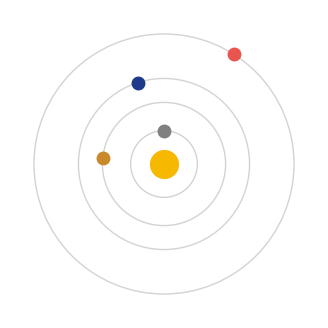

In [5]:
fig, axes = plt.subplots(figsize=(4, 4))
draw_planets(axes, 0.3)          # the solar system at time 0.3 years
plt.show()

## Step 4: make it move!

A movie is just many pictures shown quickly. `FuncAnimation` calls our drawing recipe again and again,
each time a little later. Each frame moves time forward by `0.02` years (about a week). 100 frames = 2 years.

Press the ▶ button under the picture.

In [6]:
step = 0.02                      # years per frame (about one week)

def update(frame):               # frame = 0, 1, 2, ... 99
    draw_planets(axes, frame * step)

fig, axes = plt.subplots(figsize=(4, 4), dpi=72)
anim = FuncAnimation(fig, update, frames=100, interval=80)
plt.close()                      # don't print an extra still picture
HTML(anim.to_jshtml())

Watch carefully: **Mercury races, Mars crawls**. Farther = slower. 🐢

**Try this:**
* Change `step` to `0.005`. What happens to the speed of the movie?
* Change Mars's period in the lists to `0.5` and run Steps 2-4 again. Is that still "farther = slower"?

## A time-lapse: four snapshots, a quarter year apart

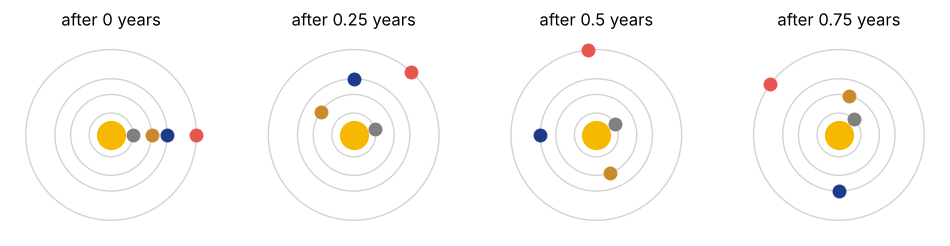

In [7]:
fig, all_axes = plt.subplots(1, 4, figsize=(12, 3.2))
snapshot_times = [0, 0.25, 0.5, 0.75]
for k in range(4):
    draw_planets(all_axes[k], snapshot_times[k])
    all_axes[k].set_title(f"after {snapshot_times[k]} years")
plt.show()

Earth (blue) does a quarter circle each time. Mercury (gray) almost does a **full** circle in a quarter year.

## Checking the AI's code: change one number, predict, run

Never trust code just because it looks nice. Three habits:

1. **Read it** - can you say what each line does?
2. **Run it** - does the output make sense?
3. **Change one number and predict** - then run and see if you were right

Here: what if Earth needed only **half a year** for one circle? Predict: after 0.25 years, where is it?

In [8]:
# 1 AU, half-year period, t = 0.25
x, y = position(1.0, 0.5, 0.25)
print(f"x = {x:.2f}, y = {y:.2f}")

x = -1.00, y = 0.00


Half a circle in a quarter year: Earth is on the **left** side (`x = -1.00`). If you predicted that - you are checking code like a pro.

## Two follow-up prompts

We asked the AI two more things in the same chat:

> *Add the Moon. Make its circle bigger than real, so we can see it.*

> *Add the planet names and a title with the day number.*

The Moon needs **two** circles: its own small one, carried along by the Earth.
The real Moon is about 0.0026 AU from Earth - at this size it would sit *on* the Earth dot - so we draw it at 0.15 AU (**not to scale**).

In [9]:
moon_distance = 0.15     # NOT to scale (the real one: about 0.0026 AU)
moon_period = 0.0748     # 27.3 days, written in years

def draw_planets_v2(axes, time):
    draw_planets(axes, time)                               # start from version 1
    for i in range(len(names)):                            # a name tag for each planet
        x, y = position(distances[i], periods[i], time)
        axes.text(x + 0.08, y + 0.08, names[i], fontsize=8)
    earth_x, earth_y = position(1.0, 1.0, time)            # where is Earth?
    moon_x, moon_y = position(moon_distance, moon_period, time)   # Moon's own little circle
    axes.plot(earth_x + moon_x, earth_y + moon_y, "o", color="dimgray", markersize=4)
    axes.set_title(f"Our solar system - day {time * 365:.0f}")

In [10]:
step = 0.01                      # smaller steps, so the fast Moon looks smooth

def update_v2(frame):
    draw_planets_v2(axes, frame * step)

fig, axes = plt.subplots(figsize=(4, 4), dpi=72)
anim = FuncAnimation(fig, update_v2, frames=100, interval=80)
plt.close()
HTML(anim.to_jshtml())

# Version 2: real gravity, gently

In Version 1 we **told** each planet to move on a circle. But nobody tells the real Earth what to do!
Our third prompt:

> *Now use real gravity instead of circles, for Earth and Mars. Explain it without calculus.*

**The idea, with zero math:** Think of a ball on a string that you swing around your head.
The string always pulls the ball **toward your hand**. The ball wants to fly straight, the string keeps bending its path - so it goes in a circle.
Or a bus turning a corner: you feel pushed sideways because the bus keeps changing direction.

For a planet, the "string" is the Sun's **gravity**. The computer repeats three tiny steps, thousands of times:

| Every tiny time step | In plain words |
|---|---|
| 1. The Sun **pulls** | a small tug toward the Sun (weaker when far away) |
| 2. The **speed changes** | the tug bends the planet's speed a little |
| 3. The planet **moves** | it moves a tiny bit with its new speed |

**Units trick:** with distances in AU and time in years, the Sun's pull strength is simply `4 * pi * pi` (about 39.5).

In [11]:
SUN_PULL = 4 * math.pi ** 2      # the Sun's pull strength, in AU and years
dt = 0.0005                      # one tiny time step = 0.0005 years (about 4 hours)

def simulate_orbit(distance, years, speed_factor=1.0):
    x, y = distance, 0.0                  # start right of the Sun
    vx, vy = 0.0, speed_factor * 2 * math.pi / math.sqrt(distance)   # moving "up"
    xs, ys = [x], [y]                     # remember the path (a trail)
    for step in range(round(years / dt)):     # repeat (Lecture 6)
        r = math.sqrt(x ** 2 + y ** 2)        # distance to the Sun
        vx = vx - SUN_PULL * x / r ** 3 * dt  # 1. pull, 2. speed changes
        vy = vy - SUN_PULL * y / r ** 3 * dt
        x, y = x + vx * dt, y + vy * dt       # 3. the planet moves
        xs.append(x)
        ys.append(y)
    return xs, ys

The start speed `2 * pi / sqrt(distance)` is the speed that keeps a planet on a circle (the AI worked it out for us).
`speed_factor=1.0` lets us try "what if it were slower?" later.

### Does Earth's orbit close after one year?
This is our **check**: if the physics is right, after exactly 1 year Earth should be back where it started.

In [12]:
earth_xs, earth_ys = simulate_orbit(1.0, 1.0)            # Earth, for 1 year
gap = math.sqrt((earth_xs[-1] - earth_xs[0]) ** 2 + (earth_ys[-1] - earth_ys[0]) ** 2)
print(f"Steps simulated: {len(earth_xs) - 1}")
print(f"Gap after 1 year: {gap:.5f} AU")
print(f"That is about {gap * 150_000_000:.0f} km")

Steps simulated: 2000
Gap after 1 year: 0.00004 AU
That is about 6589 km


(`150_000_000` is just 150000000 - the underscores only make it easier to read. The gap is smaller than the Earth itself, which is about 12,700 km wide - after a trip of about 940 million km around the Sun!)

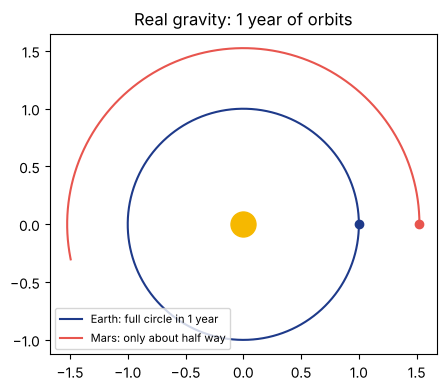

In [13]:
earth_xs, earth_ys = simulate_orbit(1.0, 1.0)
mars_xs, mars_ys = simulate_orbit(1.524, 1.0)            # Mars, also 1 year

fig, axes = plt.subplots(figsize=(5, 5))
axes.plot(earth_xs, earth_ys, color="#1E3A8A", label="Earth: full circle in 1 year")
axes.plot(mars_xs, mars_ys, color="#E8554E", label="Mars: only about half way")
axes.plot(0, 0, "o", color="#F6B800", markersize=18)    # the Sun
axes.plot(1.0, 0, "o", color="#1E3A8A")                  # Earth's start point
axes.plot(1.524, 0, "o", color="#E8554E")                # Mars's start point
axes.set_aspect("equal")
axes.set_title("Real gravity: 1 year of orbits")
axes.legend(loc="lower left", fontsize=8)
plt.show()

### How long is a "year" on each planet?

Let the simulation run and **measure** when each planet comes back to its starting line
(the first time `y` goes from negative back to zero or more). Then compare with NASA's numbers.

In [14]:
def measure_year(distance):
    xs, ys = simulate_orbit(distance, 3)                 # 3 years is enough for Mars
    for i in range(1, len(ys)):
        if ys[i - 1] < 0 and ys[i] >= 0:                 # crossed the start line again
            return i * dt                                # time in years

real_distances = [0.387, 0.723, 1.000, 1.524]            # NASA, in AU
nasa_days = [88, 225, 365, 687]                          # NASA orbital periods, in days
for i in range(4):
    sim_days = measure_year(real_distances[i]) * 365.25
    print(f"{names[i]:8} sim: {sim_days:4.0f} days  NASA: {nasa_days[i]}")

Mercury  sim:   88 days  NASA: 88
Venus    sim:  225 days  NASA: 225
Earth    sim:  365 days  NASA: 365
Mars     sim:  687 days  NASA: 687


Our tiny three-step recipe, plus the Sun's pull, **finds the real lengths of the years**. Nobody told the computer "Mars takes 687 days". 🤯

### What if Earth were a bit too slow?

Change one number: `speed_factor=0.8` (80% of the circle speed). **Predict** before you run: circle? crash into the Sun? something else?

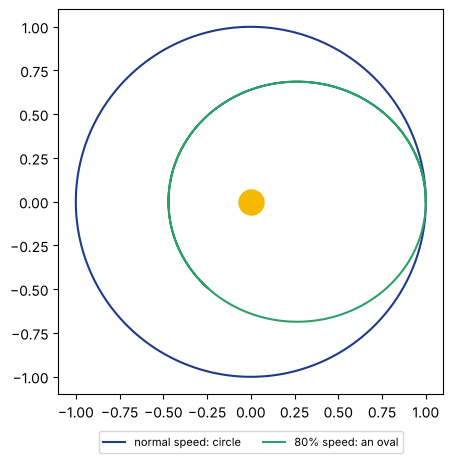

In [15]:
slow_xs, slow_ys = simulate_orbit(1.0, 1.0, speed_factor=0.8)

fig, axes = plt.subplots(figsize=(5, 5))
axes.plot(earth_xs, earth_ys, color="#1E3A8A", label="normal speed: circle")
axes.plot(slow_xs, slow_ys, color="#2E9E6B", label="80% speed: an oval")
axes.plot(0, 0, "o", color="#F6B800", markersize=18)
axes.set_aspect("equal")
axes.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=8)
plt.show()

Too slow = the Sun pulls it into an **oval** (an *ellipse*). Real planet orbits are slightly oval too!

## Farther = slower: the real numbers

A bar chart of NASA's orbital periods (you'll make bar charts yourself in Lecture 10).

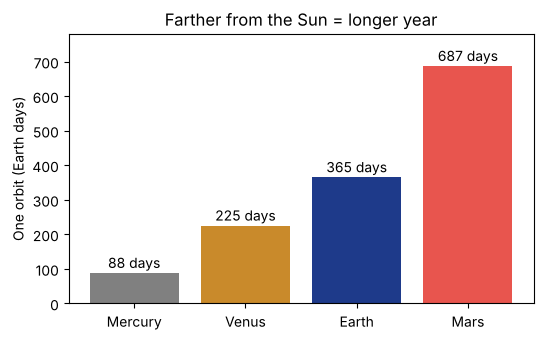

In [16]:
fig, axes = plt.subplots(figsize=(6, 3.5))
axes.bar(names, nasa_days, color=colors)
for i in range(4):
    axes.text(i, nasa_days[i] + 15, f"{nasa_days[i]} days", ha="center")
axes.set_ylabel("One orbit (Earth days)")
axes.set_title("Farther from the Sun = longer year")
axes.set_ylim(0, 780)
plt.show()

## Challenges

**Easy** 🌱
* In Step 1, find the `time` that puts Earth at the **bottom** of its circle (`y = -1.00`).
* Change the Sun's color or size in `draw_planets`.

**Medium** 🔥
* Add **Jupiter** to the lists: distance `5.2` AU, period `11.86` years. You will need a bigger picture: change the `set_xlim`/`set_ylim` numbers.
* In `simulate_orbit`, try `speed_factor=1.2`. Is the oval inside or outside the circle? Try `1.5`. What happens?

**Spicy** 🌶️
* Ask an AI assistant (PyCharm's or Colab's Gemini) to "add a second moon to Mars". **Read** its code before you run it, and **predict** what you will see. Was the AI right?
* Make `dt` 10 times bigger (`0.005`) and rerun the "does the orbit close?" check. How big is the gap now? Why do you think smaller steps are more accurate?